## Settings & imports

In [1]:
import sys
sys.path.insert(1, '../src/')
from data_utils import *
from train_and_evaluate import *

In [2]:
import json

with open('../config.json', 'r') as f:
    config = json.load(f)

DATASET = "Konstytucja"

PREPROCESSING_METHOD = config["preprocessing_method"]
HOW_MANY_OUTER_TO_REMOVE = config["how_many_outer_to_remove"]
ELEMENTS_TO_KEEP = config["elements_to_keep"]
ELEMENTS_TO_KEEP_XRF = config["elements_to_keep_xrf"]
MULTIPLICATION_WEIGHTS = config["multiplication_weights"]
DROPOUT_PROB = config["dropout_prob"]

FIGURES_PATH = config["figures_path"][DATASET]

TARGET_PATH = config["target_path"][DATASET]
CLASSES_DESCRIPTION_PATH = config["classes_description_path"][DATASET]
KONSTYTUCJA_RESULTS_PATH = config["ready_results_path"][DATASET]
XRF_PATH = config["xrf_path"][DATASET]

In [3]:
dataset = 'XRF'
book_name = 'ml'

## Loading the data

In [4]:
df = load_dataset_for_closest_class_assignment(dataset, 
                                               TARGET_PATH, 
                                               KONSTYTUCJA_RESULTS_PATH, 
                                               XRF_PATH, 
                                               ELEMENTS_TO_KEEP, 
                                               ELEMENTS_TO_KEEP_XRF)

In [5]:
classes_description_df = load_classes_description_df(CLASSES_DESCRIPTION_PATH)

In [6]:
ground_truth_df = create_ground_truth_df_for_target_data(dataset, 
                                                        TARGET_PATH, 
                                                        XRF_PATH,
                                                        classes_description_df, 
                                                        HOW_MANY_OUTER_TO_REMOVE)

### Dividing to APP, ASC, ML

In [7]:
df = select_book(df, ground_truth_df, book_name)

## Preprocessing

1. In this case, we skip removal of outer samples - it was only done for training examples to ensure the quality of training dataset. No need to do it on target dataset.

2. We skip removing columns from outside ELEMENTS_TO_KEEP (/ELEMENTS_TO_KEEP_XRF) list, as we have already done it during dataset loading.

3. There is no missing data in target dataset, so there is no need to remove anything.

In [8]:
df.dropna().shape == df.shape

True

4. For Konstytucja_indicators, we do the same preprocessing as for the training dataset (-> notebooks/inks_nn_regression.ipynb). There is no need to do it for Konstytucja_prediction (as the predicted values are similar to y from training set, which was also preprocessed). XRF data are of different nature so we leave them as they are.

So we set negative numbers to zero only for indicators.

In [9]:
if dataset == 'Konstytucja_indicators':
    df = set_negative_to_zero_v2(df, ELEMENTS_TO_KEEP)

5. For Konstytucja_indicators, we do the same preprocessing as for the training dataset (-> notebooks/inks_nn_regression.ipynb). There is no need to do it for Konstytucja_prediction (as the predicted values are similar to y from training set, which was also preprocessed). XRF data are of different nature so we leave them as they are.

So we multiply by weights only for indicators.

In [10]:
if dataset == 'Konstytucja_indicators':
    df = multiply_by_weights_v2(df, ELEMENTS_TO_KEEP, weights=MULTIPLICATION_WEIGHTS)

6. For Konstytucja_indicators, we do the same preprocessing as for the training dataset (-> notebooks/inks_nn_regression.ipynb). There is no need to do it for Konstytucja_prediction (as the predicted values are similar to y from training set, which was also preprocessed). XRF data are of different nature so we leave them as they are.

So we normalize to Fe only for indicators.

In [11]:
# if dataset == 'Konstytucja_indicators':
#     df = normalize_to_Fe_v2(df, ELEMENTS_TO_KEEP)

7. Finally, let's reset the index.

In [12]:
df.reset_index(drop=True, inplace=True)

### Converting to np.array

In [13]:
X = np.array(df.values)

### Normalizing / taking logarithm

In [14]:
if dataset == 'Konstytucja_indicators':

    X = transform_data(X, PREPROCESSING_METHOD)

### Ground truth

In [15]:
class_df = create_class_df(ground_truth_df, book_name)

In [16]:
y = class_df['Class name']
y = [str(y) for y in y]

### PCA - all points

In [17]:
from sklearn.decomposition import PCA

n_components = 2
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

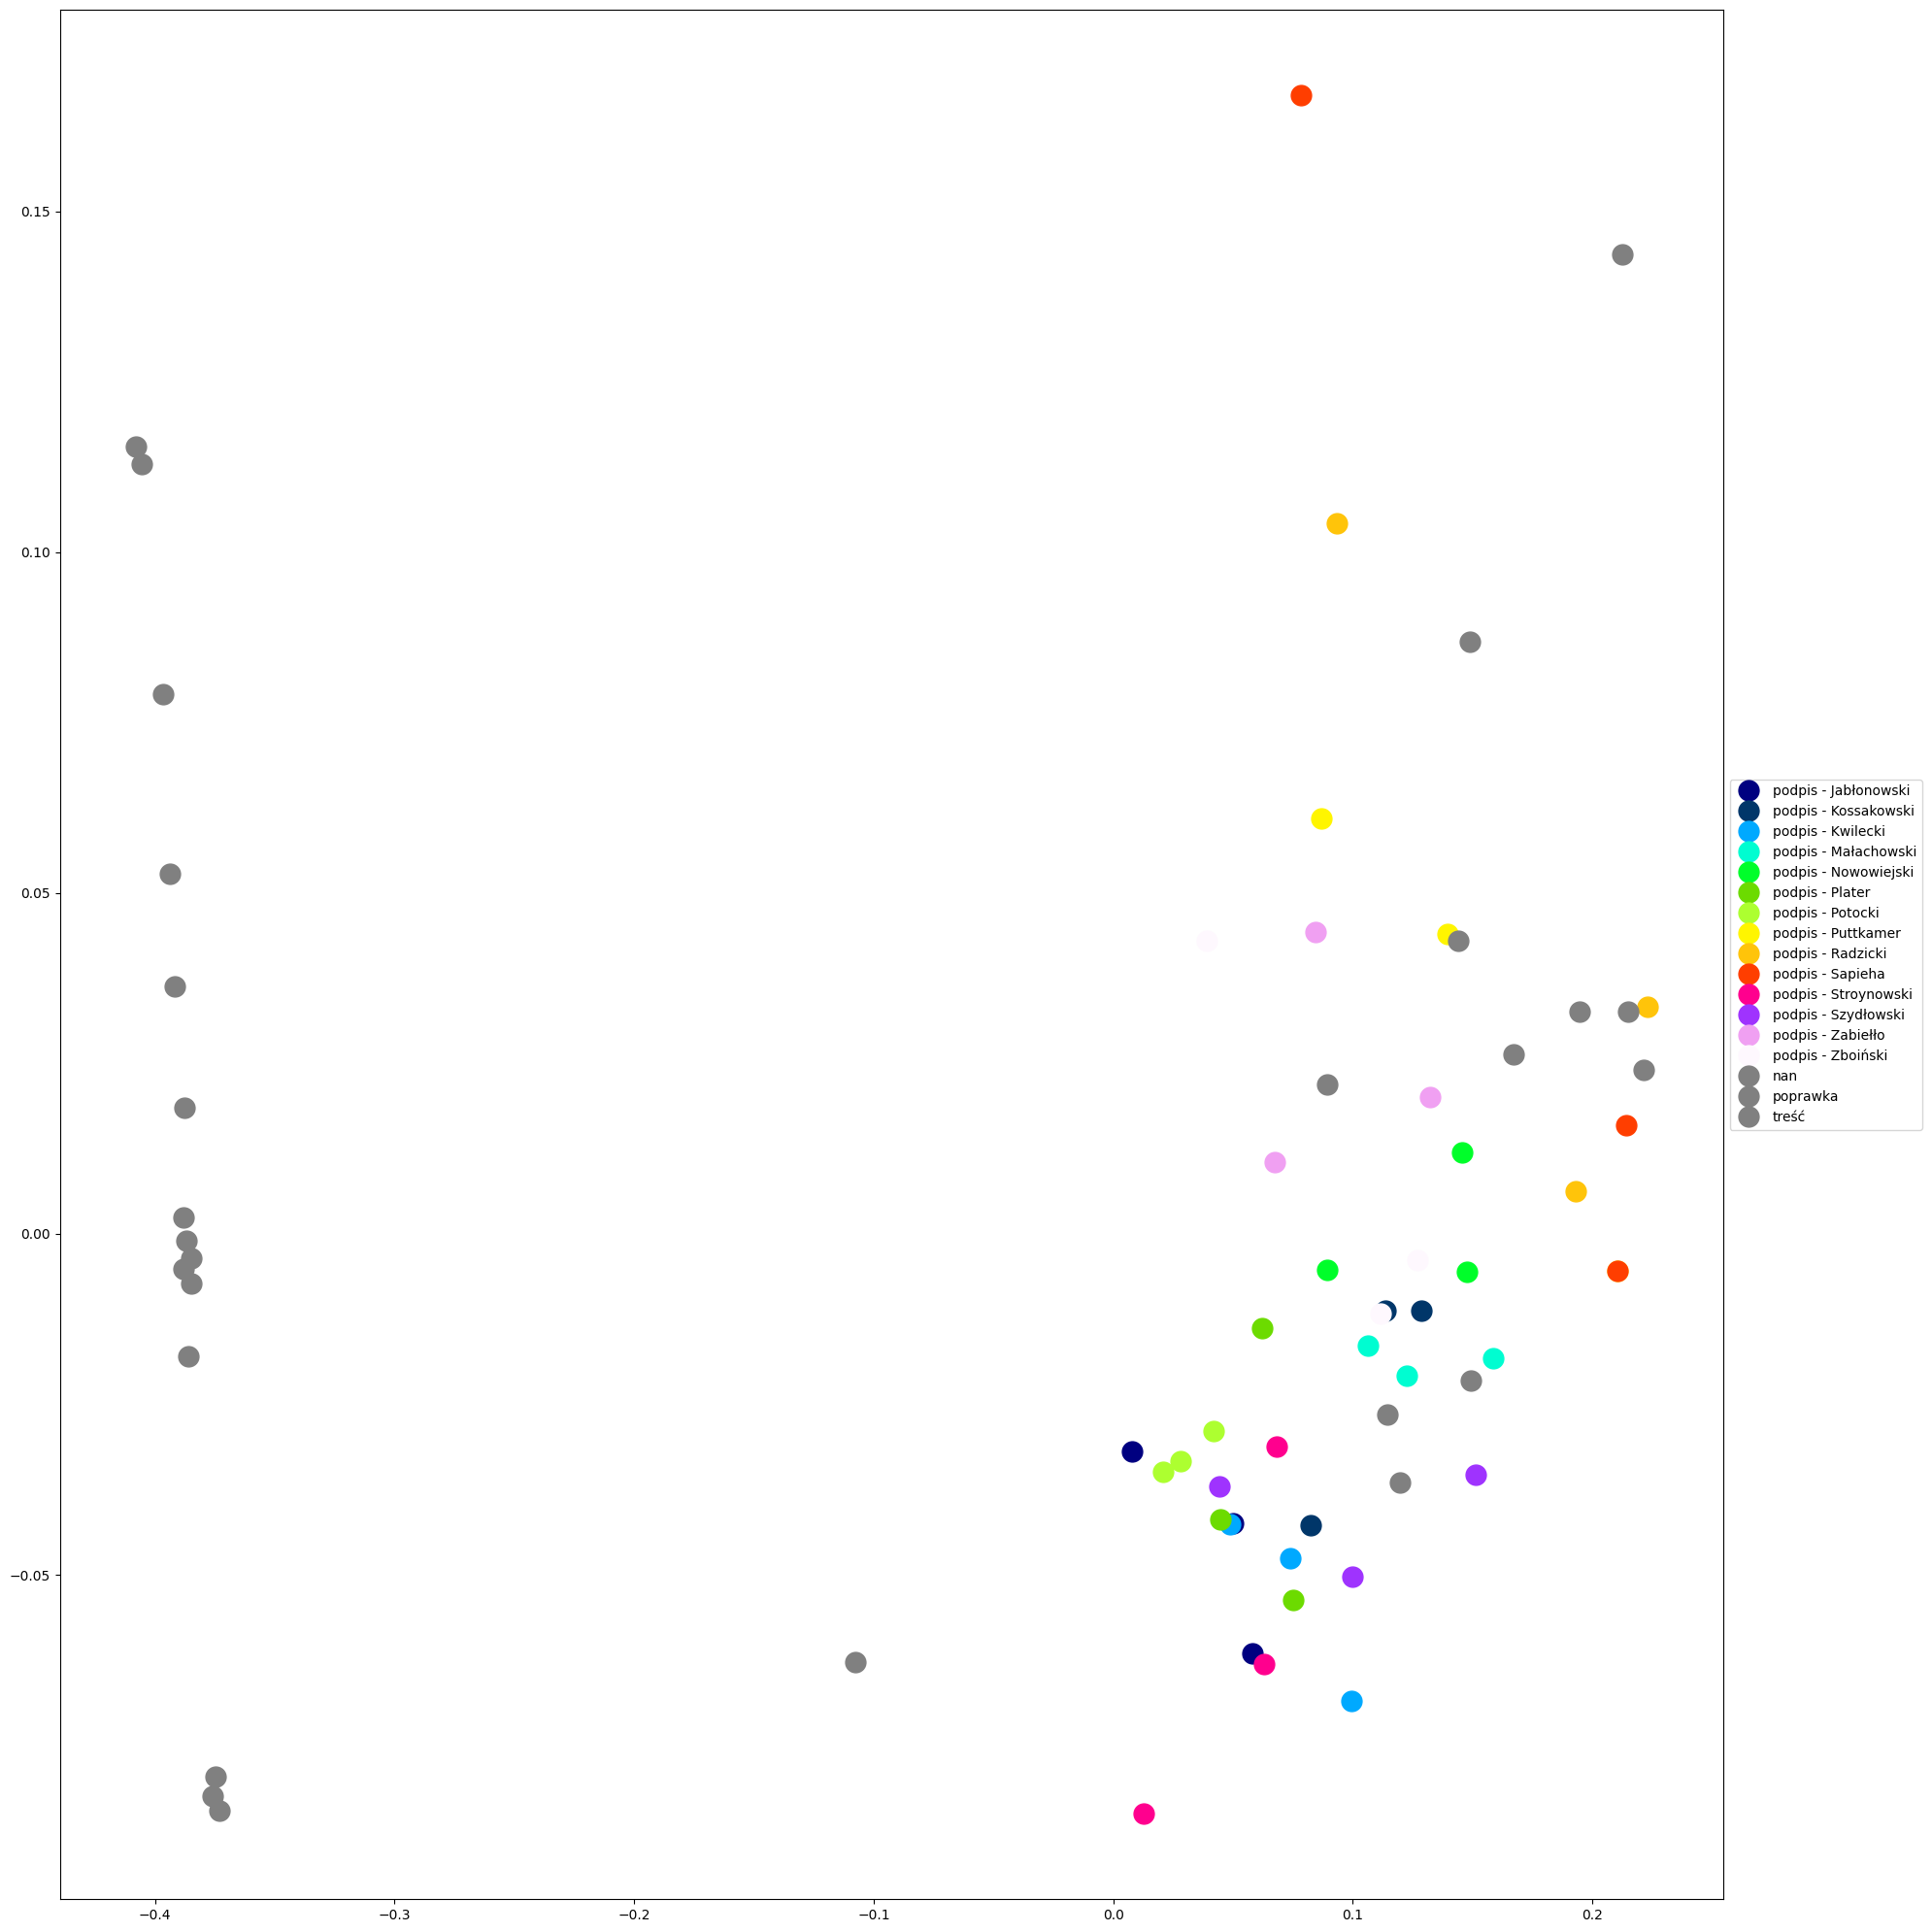

In [18]:
visualise_in_lower_dimension(X_pca, 
                            y, 
                            class_df, 
                            dataset,
                            book_name, 
                            marker_shapes = {'AS' : 'v', 'AP': 'd', 'ML': '*'}, 
                            method_name = 'pca',
                            annotate = False, 
                            figures_path=FIGURES_PATH)

### tSNE - all points

In [19]:
from sklearn.manifold import TSNE

n_components = 2
tsne = TSNE(n_components=n_components, random_state=42)
X_tsne = tsne.fit_transform(X)

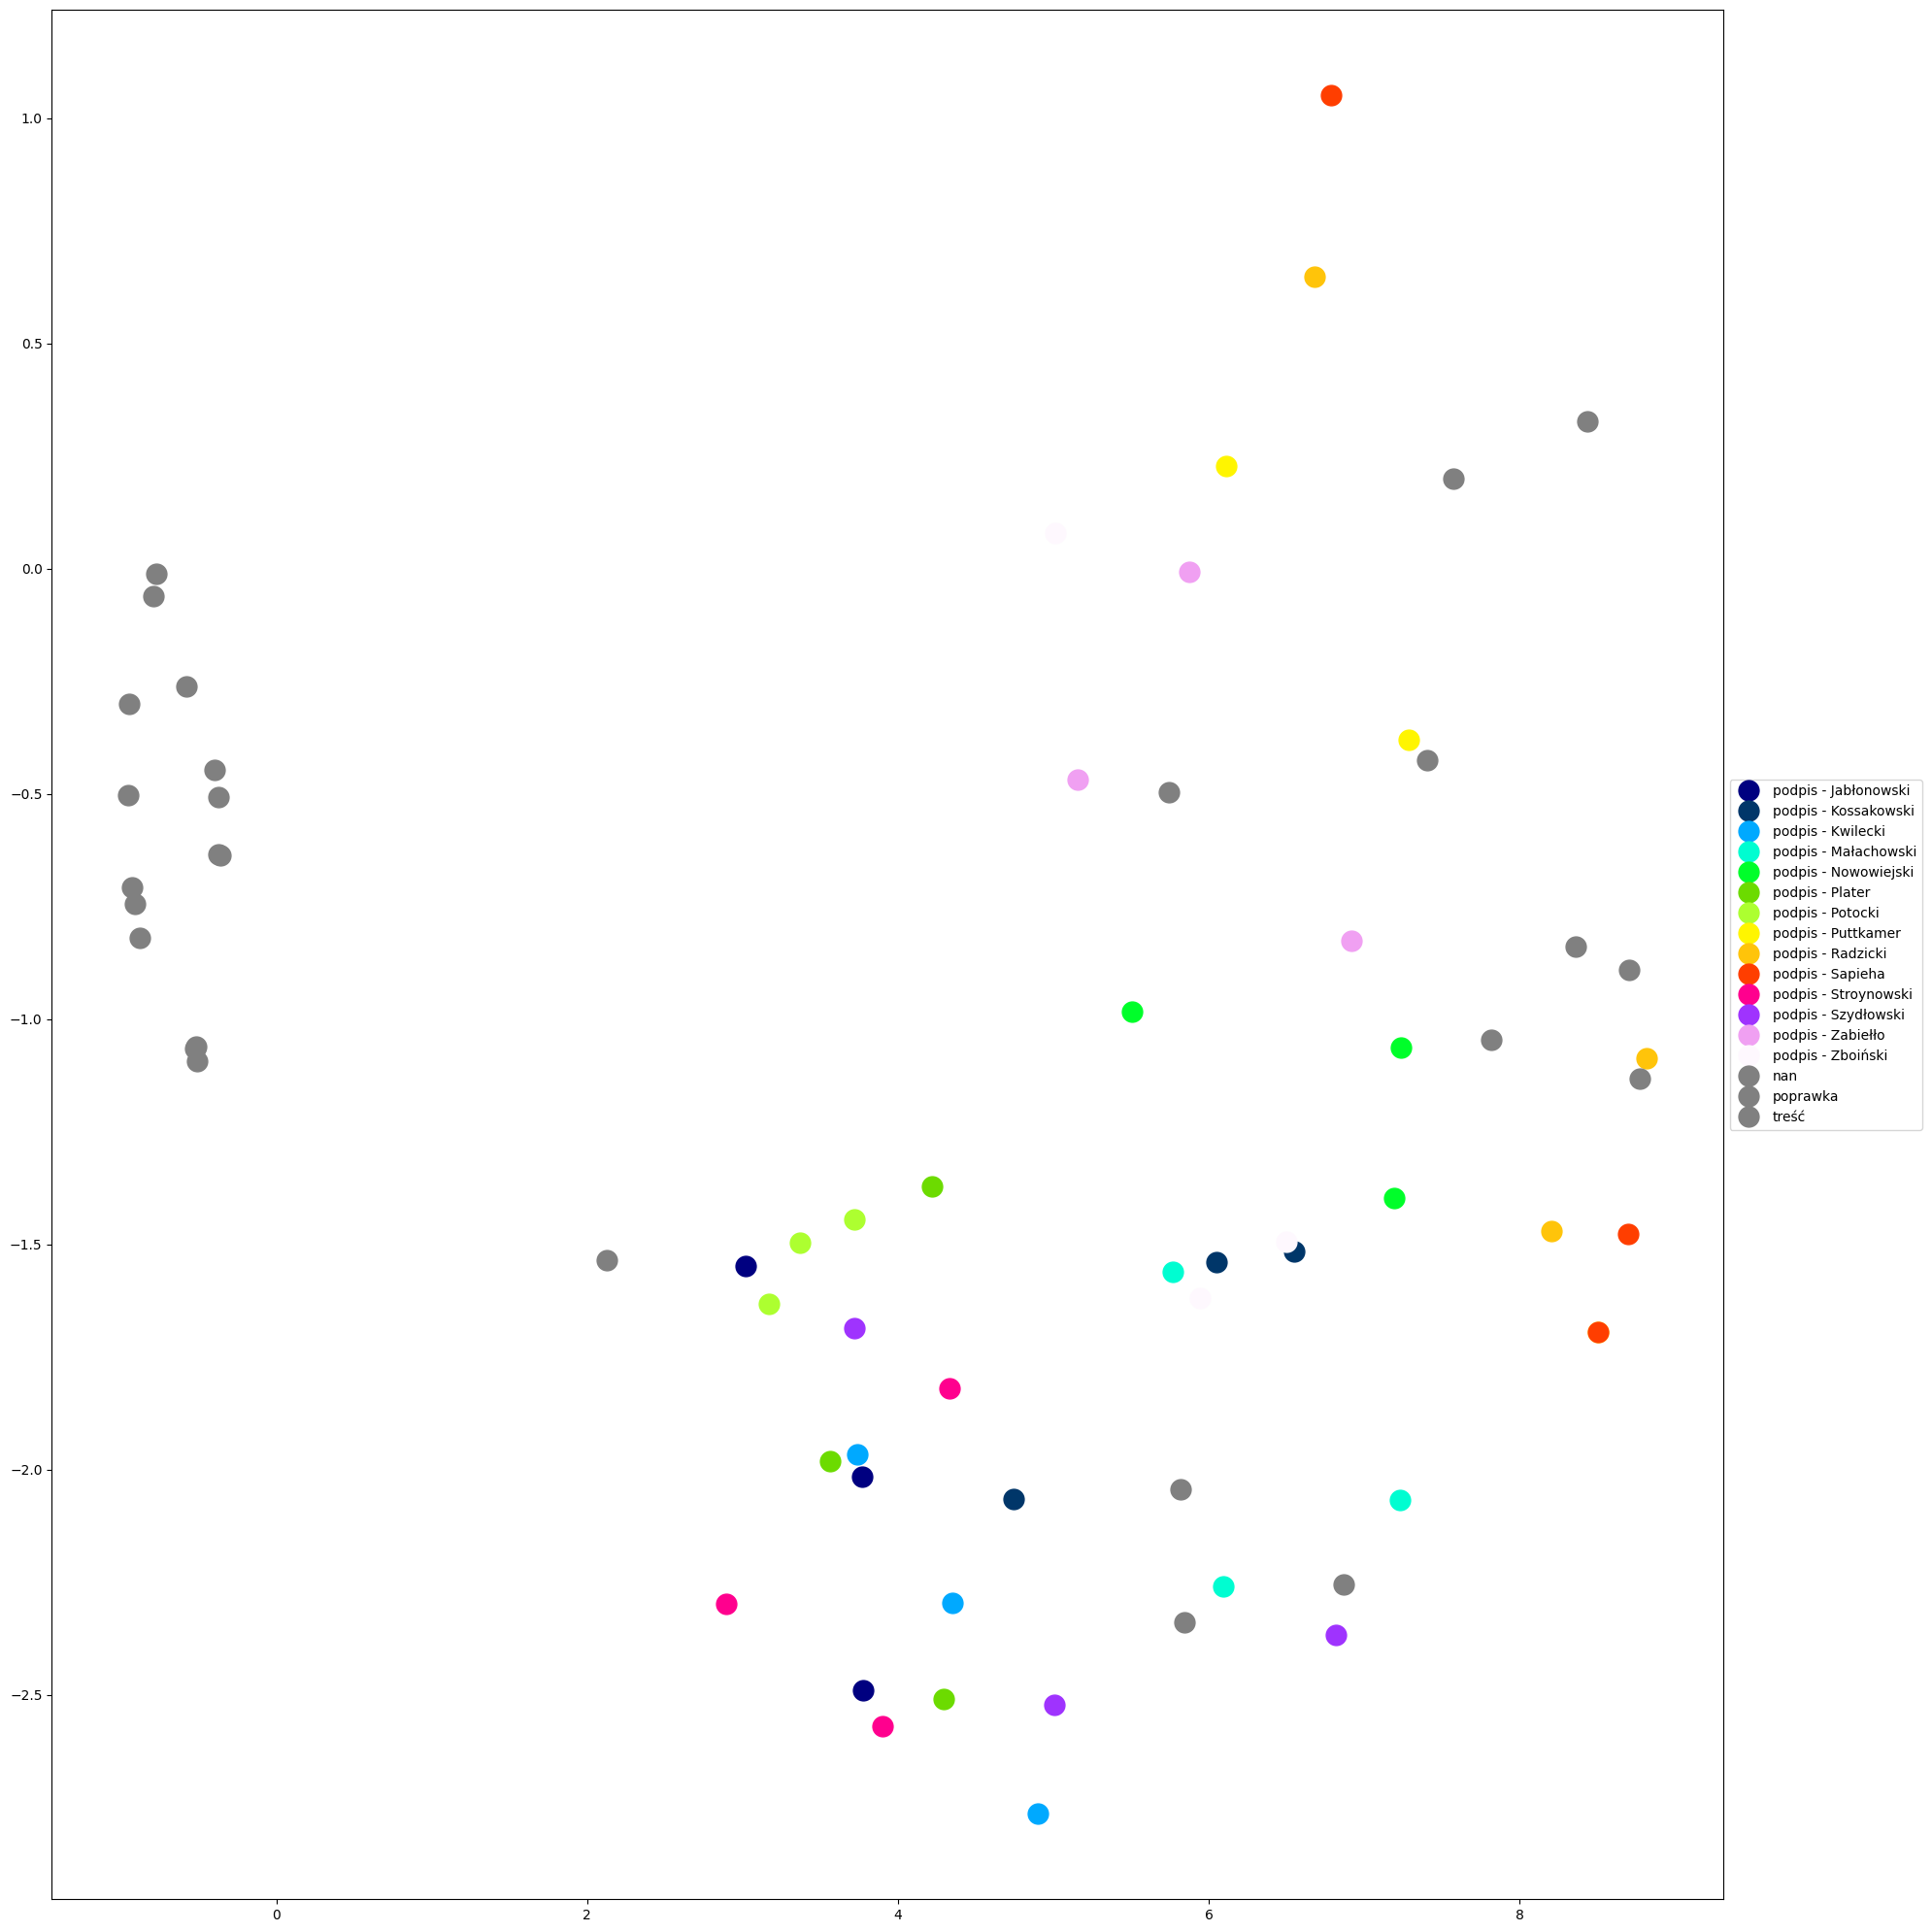

In [20]:
visualise_in_lower_dimension(X_tsne, 
                            y, 
                            class_df, 
                            dataset,
                            book_name, 
                            marker_shapes = {'AS' : 'v', 'AP': 'd', 'ML': '*'}, 
                            method_name = 'tsne',
                            annotate = False, 
                            figures_path=FIGURES_PATH)